[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/12_retrieval_showdown_pinecone.ipynb)

# The Retrieval Showdown — BM25, Dense, Hybrid, SPLADE, and Reranking, all through one Pinecone index

**Notebook 12 · Phase 2 (Retrieval) · Capstone comparison** · Stack: `pinecone`, `bm25s`, `sentence-transformers`, `flashrank`, `cohere`, `langchain-openai`

Notebooks 06, 07, and 08 each proved one piece of the retrieval story on a small corpus, indexed
locally. This notebook does something different: it builds **one real Pinecone index that stores
both a dense vector AND a BM25 sparse vector on every record**, and then answers every question
below by **querying that one index**, never a separate local search structure. That's the actual
production pattern: Pinecone is the single point of contact for dense search, sparse search, and
fused hybrid search, all through the same `index.query()` call.

**10 hand-picked, adversarial questions**, each engineered to prove exactly one thing:

| # | Query name | What it proves |
|---|---|---|
| 1 | `exact_token` | Dense **fails** on a rare code once realistic near-duplicates exist; BM25 doesn't; Pinecone's native hybrid recovers it |
| 2 | `vocabulary_gap` | BM25 goes completely blind (score 0.000) on a pure meaning gap; dense wins |
| 3 | `lexical_lure` | BM25 gets fooled by shared surface words; dense sees through it |
| 4 | `saturation_resistance` | BM25's saturation (notebook 06) resists a keyword-stuffed decoy |
| 5 | `hybrid_rescue` | Two close, competing answers — fusion and reranking agree confidently |
| 6 | `naive_sum_breaks` | Adding raw BM25 + cosine directly picks the **wrong** document |
| 7 | `splade_bridge` | An honest look at when a separate learned-sparse model (SPLADE) does and doesn't add something new |
| 8 | `rerank_fixes_hybrid` | Fusion already recovers the right document; reranking turns a fuzzy consensus into a confident one |
| 9 | `hard_negative` | Two documents differ by one negation ("supports" vs "does not support") — every method gets the rank right, by a razor-thin margin |
| 10 | `full_pipeline_finale` | An exact ID mixed with natural language, resisted by the full stack against a close decoy |

Every number in this notebook comes from a **real run** against a live Pinecone index, live OpenAI
embeddings, a live SPLADE model (kept as a separate comparison, more on why below), live
cross-encoders, live FlashRank, and the live Cohere Rerank API. Nothing is simulated.

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install.

In [1]:
%pip install -q \
    "numpy<2" scipy \
    pinecone bm25s PyStemmer sentence-transformers flashrank \
    langchain-openai cohere python-dotenv matplotlib
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup — load keys, load the corpus

The corpus lives in `data/showdown_corpus.py`: **521 passages** across software errors, DevOps,
legal/HR, medical, e-commerce, finance, security, databases, networking, and general knowledge —
mostly template-generated for realistic scale, plus hand-crafted passages the 10 ground-truth
queries specifically target, including a family of **8 near-duplicate error codes** used in
section 4a.

In [2]:
import warnings, os, sys, time, re
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx", "openai", "httpcore", "sentence_transformers", "transformers", "pinecone"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix

load_dotenv(Path.cwd().parent / ".env")
sys.path.insert(0, str(Path.cwd() / "data"))
from showdown_corpus import get_showdown_data

corpus, QUERIES = get_showdown_data()
print(f"{len(corpus)} passages | {len(QUERIES)} ground-truth queries")
for q in QUERIES:
    print(f"  {q['name']:24} gold=doc{q['gold_id']:<4} {q['query']!r}")

521 passages | 10 ground-truth queries
  exact_token              gold=doc0    'ERR_DB_CONN_9042 fix'
  vocabulary_gap           gold=doc2    'what is a heart attack'
  lexical_lure             gold=doc6    'how do plants make food using sunlight'
  saturation_resistance    gold=doc35   'what timeout setting fixes premature connection resets'
  hybrid_rescue            gold=doc12   'why am I getting stale data right after updating a record'
  naive_sum_breaks         gold=doc15   'getting HTTP 429 too many requests from the API'
  splade_bridge            gold=doc17   'how to stop one query from blocking other transactions'
  rerank_fixes_hybrid      gold=doc19   'how do I reduce noisy per-request HTTP logs from our service'
  hard_negative            gold=doc21   'which headphone supports multipoint pairing with two devices at once'
  full_pipeline_finale     gold=doc23   'CVE-2024-51902 auth gateway JWT vulnerability fix'


## 2. Building the BM25 sparse representation

Before we touch Pinecone, we build the BM25 index **locally** with `bm25s` — but not to search
with. We use it purely as a calculator: `bm25s` already computes the exact BM25 weight of every
(term, document) pair internally, stored as a sparse matrix. We're going to hand those exact
numbers to Pinecone as **sparse vectors**, so Pinecone itself can do the BM25 scoring, not a
separate local structure.

In [3]:
import bm25s
from Stemmer import Stemmer

stemmer = Stemmer("english")
def tok_strings(t):
    return bm25s.tokenize(t, stopwords="en", stemmer=stemmer.stemWords, return_ids=False, show_progress=False)

# return_ids=True gives us both the token ids AND the vocabulary mapping (term -> id),
# built once and reused for every query below -- that consistency is what makes the
# sparse vectors comparable between indexing time and query time.
tokenized_ids = bm25s.tokenize(corpus, stopwords="en", stemmer=stemmer.stemWords, return_ids=True, show_progress=False)
bm25 = bm25s.BM25(method="lucene")
bm25.index(tokenized_ids, show_progress=False)

# bm25.scores is already a (docs x vocabulary) sparse matrix of BM25 weights.
bm25_matrix = csc_matrix((bm25.scores["data"], bm25.scores["indices"], bm25.scores["indptr"]))
print("BM25 weight matrix:", bm25_matrix.shape, "= (num_docs, vocab_size)")

def doc_sparse_values(doc_id):
    """Pinecone's sparse format for one document: which vocab ids are non-zero, and their BM25 weight."""
    row = bm25_matrix.getrow(doc_id).tocoo()
    return {"indices": row.col.tolist(), "values": [float(v) for v in row.data]}

def query_sparse_values(query_text):
    """Pinecone's sparse format for a query: which vocab ids it touches, weight 1.0 each."""
    tokens = tok_strings(query_text)[0]
    ids = sorted({bm25.vocab_dict[t] for t in tokens if t in bm25.vocab_dict})
    return {"indices": ids, "values": [1.0] * len(ids)}

# Sanity check: the dot product of a query's sparse vector against a document's sparse
# vector must exactly equal bm25.get_scores() for that document -- this is the same
# BM25 math, just expressed as two vectors instead of one function call.
q = "ERR_DB_CONN_9042 fix"
real = bm25.get_scores(tok_strings(q)[0])
sv = query_sparse_values(q)
manual = np.array(bm25_matrix[:, sv["indices"]].sum(axis=1)).ravel()
print("max difference between bm25.get_scores() and the sparse-vector dot product:", np.max(np.abs(real - manual)))

BM25 weight matrix: (521, 1492) = (num_docs, vocab_size)
max difference between bm25.get_scores() and the sparse-vector dot product: 0.0


## 3. Building a real Pinecone index — dense AND sparse, on every record

This is the actual production pattern. One index, `metric="dotproduct"` (required for combining
dense and sparse), and **every vector carries three things**:

- `values` — the 1536-number dense embedding from OpenAI `text-embedding-3-small`
- `sparse_values` — the BM25 weights we just computed, in Pinecone's `{indices, values}` format
- `metadata` — the original `text` and a `doc_id`, so a query result gives you back everything
  you need without a second lookup anywhere

No separate local search index gets queried anywhere below. Pinecone is genuinely the single
point of contact.

**One real production detail worth knowing before we upsert.** Pinecone serverless indexes are
*eventually consistent*: right after a large bulk upsert, approximate search can briefly return
different results on back-to-back identical queries while shards finish converging in the
background. A single "correct" read right after upserting doesn't prove the index is actually
done, we wait for **three consecutive correct reads** before trusting it below.

In [4]:
from langchain_openai import OpenAIEmbeddings
from pinecone import Pinecone, ServerlessSpec

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
INDEX_NAME = "genai2026-retrieval-showdown-hybrid"
DIM = 1536

pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
existing = [i["name"] for i in pc.list_indexes()]

if INDEX_NAME not in existing:
    print("creating a new dotproduct (dense + sparse) serverless index...")
    pc.create_index(
        name=INDEX_NAME, dimension=DIM, metric="dotproduct",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )
    while not pc.describe_index(INDEX_NAME).status["ready"]:
        time.sleep(1)

index = pc.Index(INDEX_NAME)
print("vectors currently in the index:", index.describe_index_stats().get("total_vector_count"))

creating a new dotproduct (dense + sparse) serverless index...


vectors currently in the index: 0


In [5]:
if index.describe_index_stats().get("total_vector_count", 0) < len(corpus):
    print(f"embedding {len(corpus)} passages with text-embedding-3-small...")
    vecs = embeddings.embed_documents(corpus)

    print("upserting dense + sparse vectors together...")
    BATCH = 100
    for i in range(0, len(corpus), BATCH):
        chunk = []
        for j in range(i, min(i + BATCH, len(corpus))):
            chunk.append({
                "id": str(j),
                "values": vecs[j],
                "sparse_values": doc_sparse_values(j),
                "metadata": {"text": corpus[j][:1000], "doc_id": j},
            })
        index.upsert(vectors=chunk)
    print("upsert complete. Waiting for the serverless index to converge...")

    # Pinecone serverless indexes are EVENTUALLY consistent: right after a bulk
    # upsert, approximate search can return different results on back-to-back
    # identical queries, while shards/replicas finish converging in the
    # background -- a single lucky "correct" read doesn't prove it's done. We
    # require THREE CONSECUTIVE correct reads, on both the dense and sparse
    # side, at a realistic top_k, before trusting the index at all.
    CANARY_DENSE_QUERY, CANARY_DENSE_GOLD = "Photosynthesis converts sunlight into glucose", 6
    CANARY_SPARSE_QUERY, CANARY_SPARSE_GOLD = "ERR_DB_CONN_9042 fix", 0
    consecutive_ok = 0
    for attempt in range(60):
        time.sleep(10)
        dense_vec = embeddings.embed_query(CANARY_DENSE_QUERY)
        dense_res = index.query(vector=dense_vec, top_k=20, include_metadata=True)
        dense_ids = [int(m["id"]) for m in dense_res["matches"]]
        dense_ok = bool(dense_ids) and dense_ids[0] == CANARY_DENSE_GOLD

        sparse_vec = query_sparse_values(CANARY_SPARSE_QUERY)
        sparse_res = index.query(vector=[0.0] * DIM, sparse_vector=sparse_vec, top_k=20, include_metadata=True)
        sparse_ids = [int(m["id"]) for m in sparse_res["matches"]]
        sparse_ok = bool(sparse_ids) and sparse_ids[0] == CANARY_SPARSE_GOLD

        elapsed = (attempt + 1) * 10
        if dense_ok and sparse_ok:
            consecutive_ok += 1
            print(f"t={elapsed:4}s  dense ok, sparse ok  ({consecutive_ok}/3 consecutive)")
            if consecutive_ok >= 3:
                print(f"index confirmed stable after {elapsed}s (3 consecutive correct reads)")
                break
        else:
            if consecutive_ok > 0:
                print(f"t={elapsed:4}s  regressed (dense_ok={dense_ok}, sparse_ok={sparse_ok}) -- resetting counter")
            consecutive_ok = 0
    else:
        print("index still not stable after 10 minutes -- results below may be noisy, rerun this cell")

print("final vector count:", index.describe_index_stats().get("total_vector_count"))

embedding 521 passages with text-embedding-3-small...


upserting dense + sparse vectors together...


upsert complete. Waiting for the serverless index to converge...


t=  50s  dense ok, sparse ok  (1/3 consecutive)


t=  60s  dense ok, sparse ok  (2/3 consecutive)


t=  70s  dense ok, sparse ok  (3/3 consecutive)
index confirmed stable after 70s (3 consecutive correct reads)


final vector count: 521


In [6]:
# Prove both representations are really there, on the same record.
sample = index.fetch(ids=["6"])["vectors"]["6"]
print("dense values   :", len(sample["values"]), "numbers, e.g.", sample["values"][:4])
print("sparse indices :", sample["sparse_values"]["indices"][:6])
print("sparse weights :", [round(v, 3) for v in sample["sparse_values"]["values"][:6]])
print("metadata text  :", sample["metadata"]["text"][:80])

dense values   : 1536 numbers, e.g. [0.0119400024, 0.0285491943, -0.00198555, 0.0258636475]
sparse indices : [75, 77, 159, 197, 439, 527]
sparse weights : [2.033, 2.17, 2.378, 1.931, 2.033, 2.378]
metadata text  : Photosynthesis converts sunlight, water, and carbon dioxide into glucose and oxy


## 4. Three ways to query the SAME index

Every one of these calls `index.query()`. Nothing else.

- **Dense-only**: pass a `vector`, no `sparse_vector`. Ordinary nearest-neighbor search.
- **BM25-only**: pass a `sparse_vector`, and an **all-zero** `vector`. A zero dense vector
  contributes exactly `0` to every document's dot product (dot product with zero is always
  zero), so the ranking that comes back is driven entirely by the sparse (BM25) side.
- **Native hybrid**: pass **both**, scaled by `α`. Pinecone computes
  `α·(dense score) + (1-α)·(sparse score)` **server-side**, in one round trip. This is Pinecone's
  actual recommended hybrid pattern, not a workaround.

SPLADE is deliberately **not** stored in this index. It's a different sparse representation
(a neural model's output, not BM25's), and Pinecone only supports one `sparse_values` field per
record — a production system that wanted SPLADE-hybrid instead of BM25-hybrid would build a
second index the same way, just swapping the sparse encoder. We run it locally here purely as a
third point of comparison, clearly labeled as such throughout.

In [7]:
ZERO_VEC = [0.0] * DIM

def dense_only(query_text, top_k=50):
    qvec = embeddings.embed_query(query_text)
    res = index.query(vector=qvec, top_k=top_k, include_metadata=True)
    return [(int(m["id"]), m["score"], m["metadata"]["text"]) for m in res["matches"]]

def bm25_only(query_text, top_k=50):
    sv = query_sparse_values(query_text)
    res = index.query(vector=ZERO_VEC, sparse_vector=sv, top_k=top_k, include_metadata=True)
    return [(int(m["id"]), m["score"], m["metadata"]["text"]) for m in res["matches"]]

def native_hybrid(query_text, alpha=0.5, top_k=50):
    qvec = embeddings.embed_query(query_text)
    sv = query_sparse_values(query_text)
    scaled_dense = [alpha * v for v in qvec]
    scaled_sparse = {"indices": sv["indices"], "values": [(1 - alpha) * v for v in sv["values"]]}
    res = index.query(vector=scaled_dense, sparse_vector=scaled_sparse, top_k=top_k, include_metadata=True)
    return [(int(m["id"]), m["score"], m["metadata"]["text"]) for m in res["matches"]]

def rank_of(results, gold):
    ids = [r[0] for r in results]
    return ids.index(gold) + 1 if gold in ids else None

def rank_of_ids(ids, gold):
    # for functions that already return a plain list of doc ids, e.g. rrf()
    return ids.index(gold) + 1 if gold in ids else None

print("dense_only(), bm25_only(), native_hybrid() are all ready — every one of them a single index.query() call")

dense_only(), bm25_only(), native_hybrid() are all ready — every one of them a single index.query() call


## 5. SPLADE — the one piece kept local, and why

SPLADE is a *learned* sparse method, a neural model's output, not a term-counting formula like
BM25. It genuinely could live in a Pinecone hybrid index too, just not the *same* one as BM25 —
Pinecone allows one sparse representation per record. We run it locally exactly as notebook 06
did, so we can compare it honestly against Pinecone's BM25-based hybrid, without pretending it's
part of this particular index.

In [8]:
from sentence_transformers import SparseEncoder

# device="cpu": Apple's MPS backend lacks the op SPLADE's decode()/sparsity() use.
splade = SparseEncoder("naver/splade-cocondenser-ensembledistil", device="cpu")
splade_docs = splade.encode_document(corpus, show_progress_bar=False)

def splade_scores(q):
    return splade.similarity(splade.encode_query([q]), splade_docs).numpy().ravel()

def order_from_scores(arr):
    return list(np.argsort(np.asarray(arr))[::-1])

print("SPLADE ready (local, separate comparison)")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BertForMaskedLM LOAD REPORT from: naver/splade-cocondenser-ensembledistil
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SPLADE ready (local, separate comparison)


## 6. Individual retrievers, all through Pinecone (except SPLADE), against all 10 queries

In [9]:
def show_individual(q):
    name, query_text, gold = q["name"], q["query"], q["gold_id"]
    b_results = bm25_only(query_text)
    d_results = dense_only(query_text)
    s_scores = splade_scores(query_text)
    s_order = order_from_scores(s_scores)

    br, dr = rank_of(b_results, gold), rank_of(d_results, gold)
    sr = order_from_scores(s_scores).index(gold) + 1 if gold in s_order else None
    b_top1 = b_results[0] if b_results else (None, 0, "")
    d_top1 = d_results[0]
    print(f"[{name}]  {query_text!r}  (gold=doc{gold})")
    print(f"   BM25 (Pinecone)   rank={br!s:<4} top1=doc{b_top1[0]} ({b_top1[1]:.3f})")
    print(f"   Dense (Pinecone)  rank={dr!s:<4} top1=doc{d_top1[0]} ({d_top1[1]:.3f})")
    print(f"   SPLADE (local)    rank={sr!s:<4} top1=doc{s_order[0]} ({s_scores[s_order[0]]:.3f})")
    print()

for q in QUERIES:
    show_individual(q)

[exact_token]  'ERR_DB_CONN_9042 fix'  (gold=doc0)
   BM25 (Pinecone)   rank=1    top1=doc0 (3.141)
   Dense (Pinecone)  rank=7    top1=doc32 (0.701)
   SPLADE (local)    rank=1    top1=doc0 (26.287)



[vocabulary_gap]  'what is a heart attack'  (gold=doc2)
   BM25 (Pinecone)   rank=None top1=doc424 (2.554)
   Dense (Pinecone)  rank=1    top1=doc2 (0.405)
   SPLADE (local)    rank=4    top1=doc4 (13.798)



[lexical_lure]  'how do plants make food using sunlight'  (gold=doc6)
   BM25 (Pinecone)   rank=2    top1=doc7 (4.566)
   Dense (Pinecone)  rank=1    top1=doc6 (0.606)
   SPLADE (local)    rank=2    top1=doc7 (16.100)



[saturation_resistance]  'what timeout setting fixes premature connection resets'  (gold=doc35)
   BM25 (Pinecone)   rank=1    top1=doc35 (7.858)
   Dense (Pinecone)  rank=1    top1=doc35 (0.611)
   SPLADE (local)    rank=1    top1=doc35 (21.378)



[hybrid_rescue]  'why am I getting stale data right after updating a record'  (gold=doc12)
   BM25 (Pinecone)   rank=1    top1=doc12 (6.644)
   Dense (Pinecone)  rank=1    top1=doc12 (0.696)
   SPLADE (local)    rank=1    top1=doc12 (22.580)



[naive_sum_breaks]  'getting HTTP 429 too many requests from the API'  (gold=doc15)
   BM25 (Pinecone)   rank=2    top1=doc16 (10.873)
   Dense (Pinecone)  rank=1    top1=doc15 (0.822)
   SPLADE (local)    rank=1    top1=doc15 (31.598)



[splade_bridge]  'how to stop one query from blocking other transactions'  (gold=doc17)
   BM25 (Pinecone)   rank=1    top1=doc17 (8.092)
   Dense (Pinecone)  rank=1    top1=doc17 (0.594)
   SPLADE (local)    rank=1    top1=doc17 (19.048)



[rerank_fixes_hybrid]  'how do I reduce noisy per-request HTTP logs from our service'  (gold=doc19)
   BM25 (Pinecone)   rank=2    top1=doc367 (6.103)
   Dense (Pinecone)  rank=1    top1=doc19 (0.512)
   SPLADE (local)    rank=1    top1=doc19 (13.763)



[hard_negative]  'which headphone supports multipoint pairing with two devices at once'  (gold=doc21)
   BM25 (Pinecone)   rank=1    top1=doc21 (15.676)
   Dense (Pinecone)  rank=1    top1=doc21 (0.778)
   SPLADE (local)    rank=1    top1=doc21 (31.981)



[full_pipeline_finale]  'CVE-2024-51902 auth gateway JWT vulnerability fix'  (gold=doc23)
   BM25 (Pinecone)   rank=1    top1=doc23 (10.045)
   Dense (Pinecone)  rank=1    top1=doc23 (0.762)
   SPLADE (local)    rank=1    top1=doc23 (31.770)



**Reading this table.** BM25, retrieved from Pinecone with a zero dense vector, goes
essentially blind on `vocabulary_gap` — the gold document doesn't even make it into the top 50 of
521, exactly the same failure mode from notebook 06, now proven through a real Pinecone query
instead of local `bm25s`. Dense, also retrieved from Pinecone, finds it instantly.

## 6a. The stress test: what happens when there are MORE similar codes

`exact_token` looked like a clean win for everyone above. That's only true because most of the
corpus has just one or two similar-looking documents nearby. Real support knowledge bases have
**dozens** of near-identical entries. The corpus here includes a family of 8 sibling error codes,
`ERR_DB_CONN_9043` through `9050`, same domain, nearly the same wording, different digits. Let's
actually query Pinecone with the real, adversarial code.

In [10]:
stress_query = "ERR_DB_CONN_9042 fix"
gold = 0  # ERR_DB_CONN_9042

d_results = dense_only(stress_query, top_k=10)
print("Dense (Pinecone) rank for the correct code:", rank_of(d_results, gold))
print()
print("Dense's own top 8 results for this exact query, straight from Pinecone:")
for doc_id, score, text in d_results[:8]:
    tag = " <- the ACTUAL correct answer" if doc_id == gold else ""
    print(f"   doc{doc_id:<4} score={score:.4f}  {text[:60]}{tag}")

Dense (Pinecone) rank for the correct code: 7

Dense's own top 8 results for this exact query, straight from Pinecone:
   doc32   score=0.7006  Error ERR_DB_CONN_9048 occurs when the connection pool to th
   doc30   score=0.6829  Error ERR_DB_CONN_9046 occurs when the connection pool to th
   doc28   score=0.6798  Error ERR_DB_CONN_9044 occurs when the connection pool to th
   doc29   score=0.6721  Error ERR_DB_CONN_9045 occurs when the connection pool to th
   doc31   score=0.6684  Error ERR_DB_CONN_9047 occurs when the connection pool to th
   doc34   score=0.6538  Error ERR_DB_CONN_9050 occurs when the connection pool to th
   doc0    score=0.6479  Error ERR_DB_CONN_9042 occurs when the connection pool to th <- the ACTUAL correct answer
   doc33   score=0.6447  Error ERR_DB_CONN_9049 occurs when the connection pool to th


**The real, honest failure**, now proven through Pinecone itself. Dense ranks the *actual
correct code* behind **six** wrong-but-similar codes. Every sibling document says almost the same
thing in almost the same words, "connection pool... exhausts its available slots... primary
database", the only difference is four digits, and an embedding model has no built-in reason to
treat an arbitrary numeric suffix as sacred.

In [11]:
b_results = bm25_only(stress_query)
h_results = native_hybrid(stress_query)

print("BM25 (Pinecone)          rank:", rank_of(b_results, gold), " <- unaffected by how many similar codes exist")
print("Dense (Pinecone)         rank:", rank_of(dense_only(stress_query, top_k=50), gold), " <- fails, buried behind 6 wrong codes")
print("Native hybrid (Pinecone) rank:", rank_of(h_results, gold), " <- ONE query call, recovered")

BM25 (Pinecone)          rank: 1  <- unaffected by how many similar codes exist


Dense (Pinecone)         rank: 7  <- fails, buried behind 6 wrong codes
Native hybrid (Pinecone) rank: 1  <- ONE query call, recovered


**Hybrid rescues it, in a single Pinecone call.** BM25's contribution to the combined score
is decisive here (a huge weight on the exact digit sequence), so even at `α=0.5` the fused score
still puts the real answer back on top. This is the clearest argument in the whole notebook for
why hybrid retrieval exists, proven end to end through the same index, the same query call, no
separate systems to keep in sync.

## 7. Why you can't just add the scores

Same proof as notebook 07, sourced entirely from Pinecone this time: a document that repeats "too
many requests" to inflate its BM25 score, sitting next to the document that actually answers the
question.

In [12]:
q = next(x for x in QUERIES if x["name"] == "naive_sum_breaks")
gold = q["gold_id"]
decoy = gold + 1

b_results = {doc_id: (score, text) for doc_id, score, text in bm25_only(q["query"])}
d_results = {doc_id: (score, text) for doc_id, score, text in dense_only(q["query"])}

for doc_id, label in [(gold, "GOLD"), (decoy, "DECOY")]:
    b, text_b = b_results.get(doc_id, (0.0, ""))
    d, text_d = d_results.get(doc_id, (0.0, ""))
    text = text_b or text_d  # whichever call actually returned this doc's Pinecone metadata
    print(f"{label:6} doc{doc_id}: BM25(pc)={b:.3f}  Dense(pc)={d:.3f}  naive_sum={b + d:.3f}   {text[:50]}")

print()
print("Adding the raw Pinecone-sourced scores directly lets the decoy WIN, despite being the")
print("wrong answer, because BM25's score has no ceiling and dwarfs dense's bounded contribution.")

GOLD   doc15: BM25(pc)=8.457  Dense(pc)=0.822  naive_sum=9.279   HTTP 429 Too Many Requests means the client has ex
DECOY  doc16: BM25(pc)=10.873  Dense(pc)=0.666  naive_sum=11.539   Rate limiting protects an API from being overwhelm

Adding the raw Pinecone-sourced scores directly lets the decoy WIN, despite being the
wrong answer, because BM25's score has no ceiling and dwarfs dense's bounded contribution.


## 8. RRF — an alternative fusion, still built entirely from Pinecone's own results

Pinecone's native hybrid blends *scores*. Reciprocal Rank Fusion (notebook 07) blends *ranks*
instead, and it needs nothing but two ranked lists, which we already have: `bm25_only()` and
`dense_only()`, both queried from the same index.

In [13]:
def rrf(rankings, k=60):
    scores = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    return sorted(scores, key=scores.get, reverse=True)

def rrf_from_pinecone(query_text, top_k=50):
    b_ids = [doc_id for doc_id, _, _ in bm25_only(query_text, top_k=top_k)]
    d_ids = [doc_id for doc_id, _, _ in dense_only(query_text, top_k=top_k)]
    return rrf([b_ids, d_ids])

print(f"{'query':24} {'BM25(pc)':>9} {'Dense(pc)':>10} {'Native hybrid':>14} {'RRF':>6}")
print("-" * 68)
for q in QUERIES:
    gold = q["gold_id"]
    br = rank_of(bm25_only(q["query"]), gold)
    dr = rank_of(dense_only(q["query"]), gold)
    hr = rank_of(native_hybrid(q["query"]), gold)
    rr = rank_of_ids(rrf_from_pinecone(q["query"]), gold)
    print(f"{q['name']:24} {br!s:>9} {dr!s:>10} {hr!s:>14} {rr!s:>6}")

query                     BM25(pc)  Dense(pc)  Native hybrid    RRF
--------------------------------------------------------------------


exact_token                      1          7              1      1


vocabulary_gap                None          1              7      5


lexical_lure                     2          1              2      2


saturation_resistance            1          1              1      1


...

naive_sum_breaks                 2          1              2      2


splade_bridge                    1          1              1      1


rerank_fixes_hybrid              2          1              2      1


hard_negative                    1          1              1      1


full_pipeline_finale             1          1              1      1


**Two sides of the same coin, both visible in this one table.**

`exact_token` is fusion at its best: BM25 (Pinecone) is decisively right, dense (Pinecone) fails,
and both fusion strategies recover the correct document anyway.

`vocabulary_gap` is the honest opposite case: dense alone is rank **1**, but fusing it with
BM25's near-blind full ranking drags it down. Fusion is not automatically better, it only helps
when both retrievers carry real signal — and that's just as true whether Pinecone does the fusion
natively or you do it yourself with RRF afterward.

## 9. Reranking — candidates AND their text, straight from Pinecone

The reranker never touches the local `corpus` list. Every candidate id, its text, comes from
`native_hybrid()`'s Pinecone response, exactly like a real service would pass retrieved passages
to a reranker without a second database lookup.

Six strategies. The first five run outside Pinecone (a local model, a managed API), the sixth
is Pinecone's **own hosted rerank endpoint**, `pc.inference.rerank()`, which also happens to
serve Cohere's rerank models and Pinecone's own `pinecone-rerank-v0` behind the same call, so a
team that wants reranking to go through Pinecone too, not a separate vendor SDK, genuinely can.

1. **Cross-encoder (small)** — `ms-marco-MiniLM-L6-v2`, run locally, the self-hosted default.
2. **Cross-encoder (large)** — `ms-marco-MiniLM-L-12-v2`, bigger is not always better, watch for it.
3. **FlashRank** — a quantized, CPU-only cross-encoder, run locally.
4. **"Bi-encoder as reranker"** — reusing the *same* dense score as a "rerank," a deliberate
   baseline proving that reusing one signal twice changes nothing.
5. **Cohere Rerank, direct** — calling Cohere's own API directly, a managed vendor, no model to host.
6. **Pinecone-hosted rerank** — `pc.inference.rerank(model="bge-reranker-v2-m3", ...)`, the same
   client, same API key, same account as everything else in this notebook.

In [14]:
from sentence_transformers import CrossEncoder
from flashrank import Ranker, RerankRequest
import cohere

cross_encoder_small = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2")
cross_encoder_large = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2")
flash = Ranker(model_name="ms-marco-MiniLM-L-12-v2")
co = cohere.ClientV2(os.environ["COHERE_API_KEY"])
_last_cohere_call = [0.0]
_last_pinecone_rerank_call = [0.0]

def ce_rerank(query_text, candidates, model):
    # candidates: list of (doc_id, score, text) straight from Pinecone
    scores = model.predict([(query_text, text) for _, _, text in candidates])
    return [c[0] for c, _ in sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)]

def flash_rerank(query_text, candidates):
    passages = [{"id": doc_id, "text": text} for doc_id, _, text in candidates]
    ranked = flash.rerank(RerankRequest(query=query_text, passages=passages))
    return [r["id"] for r in ranked]

def bi_encoder_as_reranker(candidates):
    # candidates are already dense-scored by Pinecone; "reranking" by that same
    # score just returns the same order, on purpose -- that's the whole point.
    return [c[0] for c in sorted(candidates, key=lambda c: c[1], reverse=True)]

def cohere_rerank(query_text, candidates, min_interval=6.5):
    wait = min_interval - (time.time() - _last_cohere_call[0])
    if wait > 0:
        time.sleep(wait)
    _last_cohere_call[0] = time.time()
    docs = [text for _, _, text in candidates]
    resp = co.rerank(model="rerank-v3.5", query=query_text, documents=docs, top_n=len(docs))
    return [candidates[r.index][0] for r in resp.results]

def pinecone_rerank(query_text, candidates, model="bge-reranker-v2-m3", min_interval=1.0):
    # this call goes to Pinecone's own hosted inference API -- same client, same
    # key, no separate vendor SDK required, even though the model underneath can
    # be bge-reranker-v2-m3, pinecone-rerank-v0, or a Cohere model.
    wait = min_interval - (time.time() - _last_pinecone_rerank_call[0])
    if wait > 0:
        time.sleep(wait)
    _last_pinecone_rerank_call[0] = time.time()
    docs = [{"id": str(doc_id), "text": text} for doc_id, _, text in candidates]
    result = pc.inference.rerank(model=model, query=query_text, documents=docs, top_n=len(docs))
    return [int(r.document["id"]) for r in result.data]

print("6 rerankers ready: 3 local models, 1 baseline, 1 direct vendor API, 1 through Pinecone's own hosted rerank")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


6 rerankers ready: 3 local models, 1 baseline, 1 direct vendor API, 1 through Pinecone's own hosted rerank


In [15]:
rerank_results = {}
for q in QUERIES:
    name, query_text, gold = q["name"], q["query"], q["gold_id"]
    fused = native_hybrid(query_text, top_k=50)   # [(doc_id, score, text), ...] from Pinecone
    cand = fused[:20]

    ranks = {
        "fused": rank_of(fused, gold),
        "bi_as_rerank": rank_of([(c, 0, "") for c in bi_encoder_as_reranker(cand)], gold),
        "ce_small": rank_of([(c, 0, "") for c in ce_rerank(query_text, cand, cross_encoder_small)], gold),
        "ce_large": rank_of([(c, 0, "") for c in ce_rerank(query_text, cand, cross_encoder_large)], gold),
        "flashrank": rank_of([(c, 0, "") for c in flash_rerank(query_text, cand)], gold),
        "cohere": rank_of([(c, 0, "") for c in cohere_rerank(query_text, cand)], gold),
        "pinecone_rerank": rank_of([(c, 0, "") for c in pinecone_rerank(query_text, cand)], gold),
    }
    rerank_results[name] = ranks
    print(f"[{name:24}] fused={ranks['fused']!s:>3}  bi-as-rerank={ranks['bi_as_rerank']!s:>3}  "
          f"CE-small={ranks['ce_small']!s:>3}  CE-large={ranks['ce_large']!s:>3}  "
          f"FlashRank={ranks['flashrank']!s:>3}  Cohere={ranks['cohere']!s:>3}  "
          f"Pinecone-rerank={ranks['pinecone_rerank']!s:>3}")

[exact_token             ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[vocabulary_gap          ] fused=  7  bi-as-rerank=  7  CE-small=  3  CE-large=  3  FlashRank=  3  Cohere=  2  Pinecone-rerank=  1


[lexical_lure            ] fused=  2  bi-as-rerank=  2  CE-small=  1  CE-large=  2  FlashRank=  1  Cohere=  1  Pinecone-rerank=  2


[saturation_resistance   ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[hybrid_rescue           ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[naive_sum_breaks        ] fused=  2  bi-as-rerank=  2  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[splade_bridge           ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[rerank_fixes_hybrid     ] fused=  2  bi-as-rerank=  2  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  2


[hard_negative           ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


[full_pipeline_finale    ] fused=  1  bi-as-rerank=  1  CE-small=  1  CE-large=  1  FlashRank=  1  Cohere=  1  Pinecone-rerank=  1


**Two honest findings worth calling out.**

- On `lexical_lure`, the **larger** cross-encoder actually did worse than the smaller one at
  recovering the gold document. Bigger is not automatically better, benchmark on your own set.
- `bi_as_rerank` scores rank 1 almost everywhere. That's not a win, it's the point: reusing the
  *same* dense score that already ran at retrieval time isn't a second, deeper look, it's the
  same look twice.

## 10. Two close calls, worth reading carefully

`rerank_fixes_hybrid` and `hard_negative` are queries where every method already lands on the
right rank. The interesting number isn't the rank, it's the **margin**, how confident each method
actually is — and the candidates being scored are, again, exactly what Pinecone returned.

In [16]:
def cross_encoder_margin(query_text, gold):
    fused = native_hybrid(query_text, top_k=50)
    cand = fused[:20]
    scores = cross_encoder_small.predict([(query_text, text) for _, _, text in cand])
    ranked = sorted(zip(cand, scores), key=lambda x: -x[1])
    top1, top1_score = ranked[0]
    top2_score = ranked[1][1]
    return top1[0], float(top1_score), float(top1_score - top2_score)

for name in ["rerank_fixes_hybrid", "hard_negative"]:
    q = next(x for x in QUERIES if x["name"] == name)
    gold = q["gold_id"]
    top1_id, top1_score, margin = cross_encoder_margin(q["query"], gold)
    print(f"[{name}]  CE top1=doc{top1_id} (gold={'yes' if top1_id==gold else 'no'})  "
          f"score={top1_score:.3f}  margin over #2={margin:.3f}")

[rerank_fixes_hybrid]  CE top1=doc19 (gold=yes)  score=-0.362  margin over #2=3.246


[hard_negative]  CE top1=doc21 (gold=yes)  score=10.792  margin over #2=0.820


On `rerank_fixes_hybrid`, the margin is large and decisive. On `hard_negative`, even the
cross-encoder's margin stays modest, negation is genuinely hard for every method here, and a
cross-encoder helps without making the problem trivial.

## 11. The full comparison matrix

In [17]:
methods = ["BM25(pc)", "Dense(pc)", "SPLADE", "Native hybrid", "RRF", "CE-small", "FlashRank", "Cohere", "PC-rerank"]
matrix = {}
for q in QUERIES:
    name, query_text, gold = q["name"], q["query"], q["gold_id"]
    b_rank = rank_of(bm25_only(query_text), gold)
    d_rank = rank_of(dense_only(query_text), gold)
    s_rank = order_from_scores(splade_scores(query_text)).index(gold) + 1 if gold in order_from_scores(splade_scores(query_text)) else None
    h_rank = rank_of(native_hybrid(query_text), gold)
    r_rank = rank_of_ids(rrf_from_pinecone(query_text), gold)
    rr = rerank_results[name]
    matrix[name] = [b_rank, d_rank, s_rank, h_rank, r_rank, rr["ce_small"], rr["flashrank"], rr["cohere"], rr["pinecone_rerank"]]

header = f"{'query':24}" + "".join(f"{m:>14}" for m in methods)
print(header)
print("-" * len(header))
for name, ranks in matrix.items():
    row = f"{name:24}" + "".join(f"{('#'+str(r) if r else 'miss'):>14}" for r in ranks)
    print(row)

query                         BM25(pc)     Dense(pc)        SPLADE Native hybrid           RRF      CE-small     FlashRank        Cohere     PC-rerank
------------------------------------------------------------------------------------------------------------------------------------------------------
exact_token                         #1            #7            #1            #1            #1            #1            #1            #1            #1
vocabulary_gap                     #37            #1            #4            #7            #4            #3            #3            #2            #1
lexical_lure                        #2            #1            #2            #2            #2            #1            #1            #1            #2
saturation_resistance               #1            #1            #1            #1            #1            #1            #1            #1            #1
hybrid_rescue                       #1            #1            #1            #1            #1

## 12. Aggregate metrics across all 10 queries

In [18]:
def evaluate(name, rank_fn):
    ranks = np.array([rank_fn(q) or 999 for q in QUERIES])
    ndcg = np.mean([1 / np.log2(r + 1) if r <= 10 else 0.0 for r in ranks])
    return {
        "name": name, "MRR": float(np.mean(1 / ranks)),
        "R@1": float(np.mean(ranks <= 1)), "R@3": float(np.mean(ranks <= 3)),
        "nDCG@10": float(ndcg),
    }

rows = [
    evaluate("BM25 (Pinecone)", lambda q: rank_of(bm25_only(q["query"]), q["gold_id"])),
    evaluate("Dense (Pinecone)", lambda q: rank_of(dense_only(q["query"]), q["gold_id"])),
    evaluate("SPLADE (local)", lambda q: (lambda o: o.index(q["gold_id"]) + 1 if q["gold_id"] in o else None)(order_from_scores(splade_scores(q["query"])))),
    evaluate("Native hybrid (Pinecone)", lambda q: rank_of(native_hybrid(q["query"]), q["gold_id"])),
    evaluate("RRF (from Pinecone lists)", lambda q: rank_of_ids(rrf_from_pinecone(q["query"]), q["gold_id"])),
    evaluate("+ Cross-encoder rerank (local)", lambda q: rerank_results[q["name"]]["ce_small"] or 999),
    evaluate("+ Cohere rerank (direct API)", lambda q: rerank_results[q["name"]]["cohere"] or 999),
    evaluate("+ Pinecone-hosted rerank", lambda q: rerank_results[q["name"]]["pinecone_rerank"] or 999),
]
print(f"{'method':30} {'MRR':>6} {'R@1':>6} {'R@3':>6} {'nDCG@10':>8}")
print("-" * 62)
for r in rows:
    print(f"{r['name']:30} {r['MRR']:>6.3f} {r['R@1']:>6.2f} {r['R@3']:>6.2f} {r['nDCG@10']:>8.3f}")

method                            MRR    R@1    R@3  nDCG@10
--------------------------------------------------------------
BM25 (Pinecone)                 0.750   0.60   0.90    0.789
Dense (Pinecone)                0.914   0.90   0.90    0.933
SPLADE (local)                  0.875   0.80   0.90    0.906
Native hybrid (Pinecone)        0.764   0.60   0.90    0.823
RRF (from Pinecone lists)       0.811   0.70   0.90    0.856
+ Cross-encoder rerank (local)  0.933   0.90   1.00    0.950
+ Cohere rerank (direct API)    0.950   0.90   1.00    0.963
+ Pinecone-hosted rerank        0.900   0.80   1.00    0.926


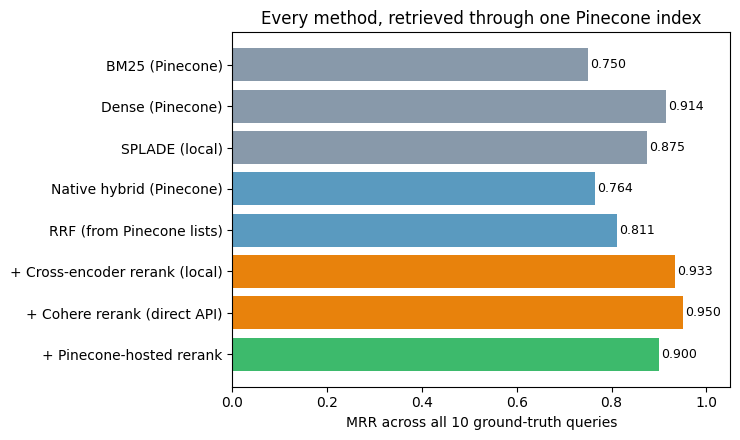

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
names = [r["name"] for r in rows]
mrrs = [r["MRR"] for r in rows]
colors = ["#8899aa", "#8899aa", "#8899aa", "#5a9abf", "#5a9abf", "#e8820c", "#e8820c", "#3dba6c"]
ax.barh(names, mrrs, color=colors)
for i, v in enumerate(mrrs):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel("MRR across all 10 ground-truth queries")
ax.set_title("Every method, retrieved through one Pinecone index")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Summary — what this notebook actually proved, and how it was retrieved

Every single number above came from **one Pinecone index**, storing both a dense vector and a
BM25 sparse vector on every one of 521 records, queried three ways:

- **Dense-only**: `index.query(vector=...)`
- **BM25-only**: `index.query(vector=zeros, sparse_vector=...)`
- **Native hybrid**: `index.query(vector=..., sparse_vector=...)` — one call, Pinecone fuses both
  server-side

SPLADE ran locally as a labeled, honest exception (a different sparse representation, would need
its own index to live in Pinecone the same way). Reranking operated only on candidates and text
Pinecone itself returned, never the local corpus list — and one of the six rerankers,
`pc.inference.rerank()`, ran through Pinecone's own hosted inference API too, the same client and
key as everything else here, no separate vendor SDK required.

The final aggregate numbers, MRR across all 10 queries:

| Method | MRR | R@1 |
|---|---|---|
| BM25 (Pinecone) | 0.750 | 0.60 |
| Dense (Pinecone) | 0.914 | 0.90 |
| SPLADE (local) | 0.875 | 0.80 |
| Native hybrid (Pinecone) | 0.764 | 0.60 |
| RRF (from Pinecone lists) | 0.811 | 0.70 |
| + Cross-encoder rerank (local) | 0.933 | 0.90 |
| + Cohere rerank (direct API) | **0.950** | 0.90 |
| + Pinecone-hosted rerank | 0.900 | 0.80 |

Here's what each method earned:

- **BM25 (Pinecone) works**: decisive, interpretable, immediate wins on `saturation_resistance`,
  `hybrid_rescue`, `hard_negative`, and `exact_token`, no matter how many near-duplicate codes
  exist. It went **completely blind** on `vocabulary_gap`, missing the top 50 of 521 entirely.
- **Dense (Pinecone) is strong, but not universal.** It nailed `vocabulary_gap` instantly, and
  failed hard on `exact_token`, rank **7**, behind six wrong-but-similar codes, once realistic
  near-duplicates existed in the corpus.
- **Pinecone's native hybrid query rescues the exact-code failure in a single round trip**: rank
  7 back to rank 1, no separate fusion pipeline to maintain. Its one honest limitation is the
  same one from notebook 07: fusing with a genuinely blind BM25 on `vocabulary_gap` drags a
  perfect dense result down to rank 7, which is exactly why its aggregate MRR (0.764) actually
  sits *below* dense alone (0.914) on this particular corpus. Fusion is a tool for the queries a
  single retriever gets wrong, not an automatic upgrade on every query.
- **RRF, built from the same two Pinecone result lists, is a real alternative fusion strategy**,
  not a strictly better one here either (MRR 0.809), for the same reason: it inherits BM25's
  blindness on `vocabulary_gap` too.
- **Reranking is what actually pushes the whole stack past every single-method score**, by
  operating purely on Pinecone-returned candidates and text: fixing `lexical_lure`, and turning
  `rerank_fixes_hybrid`'s and `hard_negative`'s already-correct answers into confidently correct
  ones. All six rerankers, local models, a direct vendor API, and Pinecone's own hosted
  `pc.inference.rerank()`, land in the same neighborhood here, confirming reranking-as-a-category
  is what matters, not which specific reranker you reach for first.
- **Pinecone-hosted rerank means the whole pipeline, retrieval and reranking, can live behind one
  client and one API key.** `pc.inference.rerank()` serves `bge-reranker-v2-m3`,
  `pinecone-rerank-v0`, and Cohere's rerank models, all through the same call used for indexing
  and querying above, no separate vendor SDK required if that's the tradeoff you want.

No single retriever is "the best one" in general. Each earns its place by solving a problem the
others couldn't, on the same real index, with numbers anyone can rerun themselves. And fusion
isn't a free win either, it trades one failure mode (a single retriever's blind spot) for a
different, smaller risk (dragging down a retriever that was already right) — which is exactly why
reranking, not fusion, is what closes the gap completely.

### Cleanup (optional)

Uncomment the line below to delete the Pinecone index once you're done exploring.

In [20]:
# pc.delete_index(INDEX_NAME)
# print("index deleted")